# Phase 1: Onset Detection & Temporal Grid Extraction

In this notebook, we set up the basic pipeline to extract music events from three different eras of Herbie Hancock's recordings. 
Our goal is to load the audio files in their native sample rates, calculate the onset strength envelope using **Spectral Flux**, and build an approximate musical beat grid.

### Analyzed Tracks:
1. **Cantaloupe Island (1964)** — Acoustic post-bop jazz (microtiming heavily relies on acoustic interaction and swing).
2. **Chameleon (1973)** — Funk-fusion featuring Fender Rhodes and synth bass (highly transient, tight electronic groove).
3. **Rockit (1983)** — Early electro-hip-hop (sequenced drum machines, early digital precision).

In [24]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import os

files = ['chameleon.wav', 'cantaloupe.wav', 'rockit.wav']
titles = {
    'chameleon.wav': 'Herbie Hancock - Chameleon',
    'cantaloupe.wav': 'Herbie Hancock - Cantaloupe Island',
    'rockit.wav': 'Herbie Hancock - Rockit'
}

audio_data = {}
sr_data = {}
onset_env_data = {}
time_data = {}

hop_length = 512

for file in files:
    path = f'../data/audio/{file}'

    y, sr = librosa.load(path, sr=None)
    audio_data[file] = y
    sr_data[file] = sr
    
    # Обчислюємо огинаючу сили атак (Spectral Flux)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    onset_env_data[file] = onset_env
    
    # Переводимо фрейми у часову шкалу
    frames = range(len(onset_env))
    t = librosa.frames_to_time(frames, sr=sr, hop_length=hop_length)
    time_data[file] = t
    
    print(f"Track: {titles[file]}")
    print(f"Audio loaded successfully! SR: {sr} Hz, Length: {len(y)} samples\n")

Track: Herbie Hancock - Chameleon
Audio loaded successfully! SR: 44100 Hz, Length: 3175200 samples

Track: Herbie Hancock - Cantaloupe Island
Audio loaded successfully! SR: 44100 Hz, Length: 3175200 samples

Track: Herbie Hancock - Rockit
Audio loaded successfully! SR: 44100 Hz, Length: 732738 samples



### Onset Detection via Spectral Flux

To find when Herbie actually strikes the keys, we use spectral domain changes. Acoustic piano hammers and Rhodes tines create a sharp increase in high-frequency energy (transients) at the moment of attack. 

We use `backtrack=True` in `librosa.onset.onset_detect`. This is crucial because a piano attack takes a few milliseconds to reach its peak amplitude; backtracking rolls the detected frame back to the actual beginning of the transient.

In [25]:
onset_times_data = {}

for file in files:
    y = audio_data[file]
    sr = sr_data[file]
    onset_env = onset_env_data[file]
    
    # Знаходимо індекси фреймів, де відбулися атаки
    onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, hop_length=hop_length, backtrack=True)
    
    # Конвертуємо індекси фреймів у секунди
    onset_times = librosa.frames_to_time(onset_frames, sr=sr, hop_length=hop_length)
    onset_times_data[file] = onset_times
    
    print(f"Track: {titles[file]}")
    print(f"Onsets detected: {len(onset_times)}")
    print(f"First 5 onsets (seconds): {onset_times[:5]}\n")

Track: Herbie Hancock - Chameleon
Onsets detected: 414
First 5 onsets (seconds): [0.06965986 0.17414966 0.3599093  0.48761905 0.73142857]

Track: Herbie Hancock - Cantaloupe Island
Onsets detected: 257
First 5 onsets (seconds): [0.02321995 0.04643991 0.29024943 0.55727891 0.78947846]

Track: Herbie Hancock - Rockit
Onsets detected: 122
First 5 onsets (seconds): [0.06965986 0.20897959 0.32507937 0.44117914 0.59210884]



### Beat Tracking & Metric Grid Construction

Now we need a global metric grid (the "theoretical" beat positions) to compare Herbie's actual timing against. 

In [26]:
beat_times_data = {}

for file in files:
    sr = sr_data[file]
    onset_env = onset_env_data[file]
    
    # Аналізуємо періодичність для пошуку темпу та ритмічної сітки
    tempo, beat_frames = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr, hop_length=hop_length)
    beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)
    beat_times_data[file] = beat_times
    
    # Безпечно отримуємо темп як число (для сумісності версій бібліотеки)
    tempo_val = tempo[0] if isinstance(tempo, (np.ndarray, list)) else tempo
    
    print(f"Track: {titles[file]}")
    print(f"Estimated Tempo: {tempo_val:.2f} BPM\n")

Track: Herbie Hancock - Chameleon
Estimated Tempo: 107.67 BPM

Track: Herbie Hancock - Cantaloupe Island
Estimated Tempo: 117.45 BPM

Track: Herbie Hancock - Rockit
Estimated Tempo: 147.66 BPM



### Auditory Verification (Ground Truth Check)

Algorithms are not perfect. We need to hear if our math aligns with physical reality:
1. `*_onsets_verify.wav` (1000 Hz high pitch clicks): Allows us to hear if the algorithm missed any soft piano attacks or triggered false positives on background noises.
2. `*_beats_verify.wav` (440 Hz lower pitch clicks): Plays a steady metronome calculated by Librosa. This lets us hear if the beat grid remains stable and "grooves" alongside the rhythm section.

In [29]:
for file in files:
    y = audio_data[file]
    sr = sr_data[file]
    
    # Очищуємо ім'я файлу від розширення для створення назв
    name = file.replace('.wav', '')
    
    # Параметри для генерації: (часові мітки, частота кліку, суфікс файлу)
    # Для бітів ставимо 3000 Гц — цей ультра-високий писк не злиється з барабанами
    tasks = [
        (onset_times_data[file], 1500, '_onsets_verify'),
        (beat_times_data[file], 3000, '_beats_verify')
    ]
    
    for times, freq, suffix in tasks:
        clicks = librosa.clicks(times=times, sr=sr, click_freq=freq, length=len(y))
        # Множимо y на 0.3, щоб приглушити трек, а самі кліки лишаємо гучними
        sf.write(f'../data/processed/{name}{suffix}.wav', (y * 0.3) + clicks, sr)
    
    print(f"Saved verification files for: {titles[file]}")

Saved verification files for: Herbie Hancock - Chameleon
Saved verification files for: Herbie Hancock - Cantaloupe Island
Saved verification files for: Herbie Hancock - Rockit


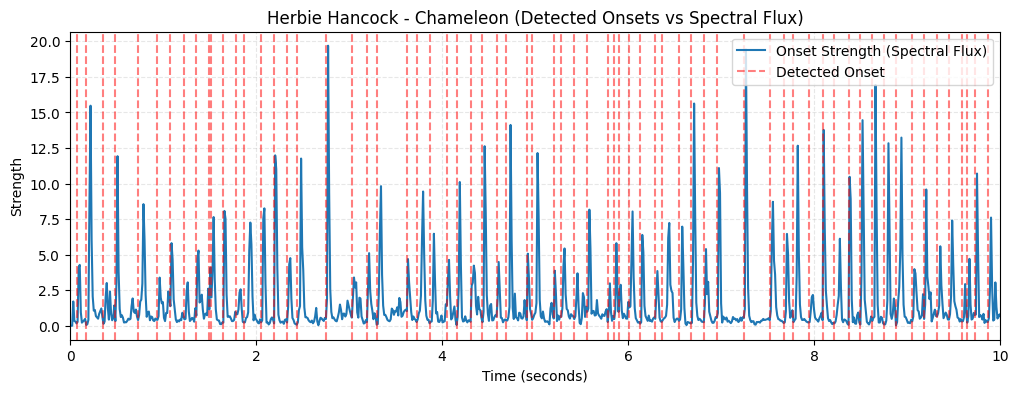

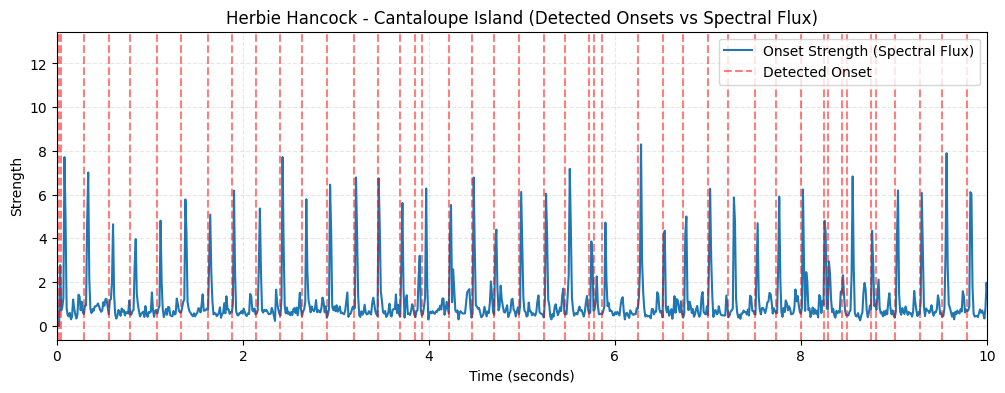

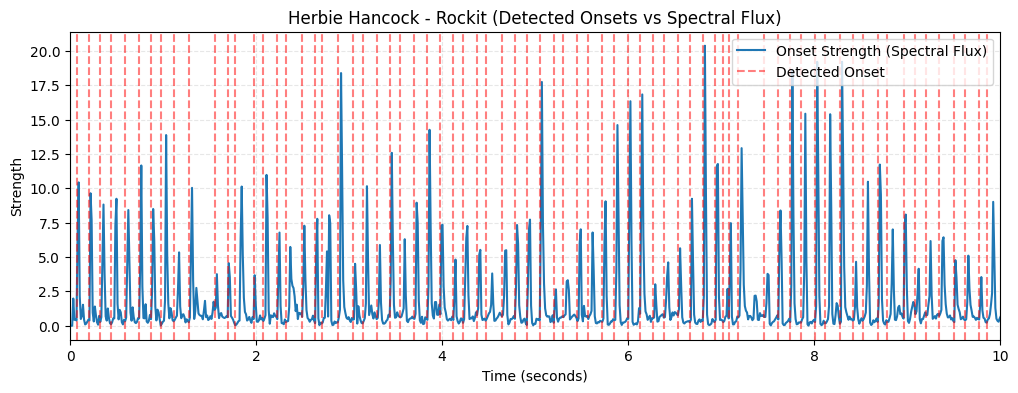

In [28]:
for file in files:
    t = time_data[file]
    onset_env = onset_env_data[file]
    onset_times = onset_times_data[file]
    
    plt.figure(figsize=(12, 4))
    plt.plot(t, onset_env, label='Onset Strength (Spectral Flux)', color='#1f77b4')
    
    # Малюємо червоні лінії для знайдених атак на проміжку перших 10 секунд
    for os_time in onset_times:
        if os_time > 10:
            break
        plt.axvline(x=os_time, color='r', linestyle='--', alpha=0.5, 
                    label='Detected Onset' if os_time == onset_times[0] else "")
        
    plt.xlim(0, 10)
    plt.title(f"{titles[file]} (Detected Onsets vs Spectral Flux)")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Strength')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

### Initial Observations & Visual Analysis

* **Acoustic vs. Electronic transients:** Looking at the *Cantaloupe Island* plot, the onset envelope peaks are generally lower (peak values ~8) and wider compared to *Chameleon* or *Rockit* (~15-20). This visually represents the physical difference between a soft acoustic felt hammer and a sharp electronic synthesizer/drum machine transient.
* **Onsets Density:** *Chameleon* has a very high onset count (414 detected points) over the same time window, showing the highly syncopated and busy nature of the clavinet/Rhodes funk performance.
* **Next Steps:** Now that we have the raw onset times and the beat grid, we can proceed to Phase 2: calculating the microtiming deviations ($\Delta t = t_{\text{onset}} - t_{\text{beat}}$) to mathematically prove who is rushing or dragging.